# reproject_image


In [1]:
source /export/ciao/bin/ciao.bash -o
PFILES="./param;$ASCDS_INSTALL/param:$ASCDS_INSTALL/contrib/param"
mkdir -p ./param
ASCDS_WORK_PATH=./


CIAO configuration is complete... 
CIAO 4.9 Friday, December  2, 2016
  bindir      : /export/ciao-4.9/bin
  CALDB       : 4.7.3


## Download

In [ ]:
/bin/rm -rf 3838 4385 4386 4387 4388 4389 4390 4391 4392 4393 4394

In [2]:
download_chandra_obsid \
   3838,4385,4386,4387,4388,4389,4390,4391,4392,4393,4394 \
   evt1,msk,fov,pbk,bias,mtl,stat,asol,bpix,flt


  Type     Format      Size  0........H.........1  Download Time Average Rate
  ---------------------------------------------------------------------------
  bpix     fits       32 Kb  ####################          < 1 s  921.5 kb/s
  fov      fits        6 Kb  ####################          < 1 s  929.6 kb/s
  asol     fits        5 Mb  ####################          < 1 s  14998.0 kb/s
  evt1     fits       42 Mb  ####################          < 1 s  43089.4 kb/s
  flt      fits        7 Kb  ####################          < 1 s  1055.9 kb/s
  msk      fits        5 Kb  ####################          < 1 s  872.7 kb/s
  mtl      fits      896 Kb  ####################          < 1 s  20746.9 kb/s
  stat     fits      624 Kb  ####################          < 1 s  10276.0 kb/s
  bias     fits      493 Kb  ####################          < 1 s  8822.7 kb/s
  bias     fits      427 Kb  ####################          < 1 s  9371.4 kb/s
  bias     fits      428 Kb  ####################          < 1

In [3]:
chandra_repro 3838,4385,4386,4387,4388,4389,4390,4391,4392,4393,4394 \
  out="" clob+



Processing input directory '/data/sdsreg/thread_output/CIAO4.9/reproject_image/3838'

Resetting afterglow status bits in evt1.fits file...

Running acis_build_badpix and acis_find_afterglow to create a new bad pixel file...

Running acis_process_events to reprocess the evt1.fits file...
Filtering the evt1.fits file by grade and status and time...
Applying the good time intervals from the flt1.fits file...
The new evt2.fits file is: /data/sdsreg/thread_output/CIAO4.9/reproject_image/3838/repro/acisf03838_repro_evt2.fits

Updating the event file header with chandra_repro HISTORY record
Creating FOV file...

Cleaning up intermediate files

The data have been reprocessed.
Start your analysis with the new products in
/data/sdsreg/thread_output/CIAO4.9/reproject_image/3838/repro


Processing input directory '/data/sdsreg/thread_output/CIAO4.9/reproject_image/4385'

Resetting afterglow status bits in evt1.fits file...

Running acis_build_badpix and acis_find_afterglow to create a new bad pi

## Using merge_obs

In [4]:
merge_obs "*/repro/*evt*[ccd_id=0:3]" sn1006/ bin=4 bands=broad,csc

Running merge_obs
Version: 12 September 2016

Verifying 11 observations.
Using CSC ACIS broad science energy band.
Using CSC ACIS soft science energy band.
Using CSC ACIS medium science energy band.
Using CSC ACIS hard science energy band.
Calculating new tangent point.
New tangent point: RA=15h 2m 56.232s Dec=-41d 56' 8.484"

Observations to be reprojected:

   Obsid  Obs Date   Exp    DETNAM     SIM_Z    FP   Sepn   PA  
                    (ks)                (mm)    (K)   (')  (deg)
----------------------------------------------------------------
 1 3838  2003-04-08  20.1 ACIS-01237  -233.587 153.4  14.2   +80
 2 4385  2003-04-08  19.8 ACIS-01237  -233.587 153.4  13.6  +125
 3 4386  2003-04-08  19.8 ACIS-01237  -233.587 153.4  13.9  +172
 4 4387  2003-04-09  19.8 ACIS-01237  -233.587 153.4  14.3  -142
 5 4388  2003-04-09  19.8 ACIS-01237  -233.587 153.4  15.1  -101
 6 4389  2003-04-09  19.8 ACIS-01237  -233.587 153.6  13.7   -56
 7 4390  2003-04-09  19.8 ACIS-01237  -233.587 153.9 

In [5]:
dmhistory sn1006/broad_flux.img merge_obs expand=no

merge_obs infiles="*/repro/*evt*[ccd_id=0:3]" outroot="sn1006/" bands="broad,csc" xygrid="" maxsize="INDEF" binsize="4" asolfiles="" badpixfiles="" maskfiles="" dtffiles="None" refcoord="" units="default" expmapthresh="1.5%" background="default" bkgparams="[pi=300:500]" random="0" parallel="yes" nproc="INDEF" tmpdir="./" cleanup="yes" clobber="no" verbose="1" 



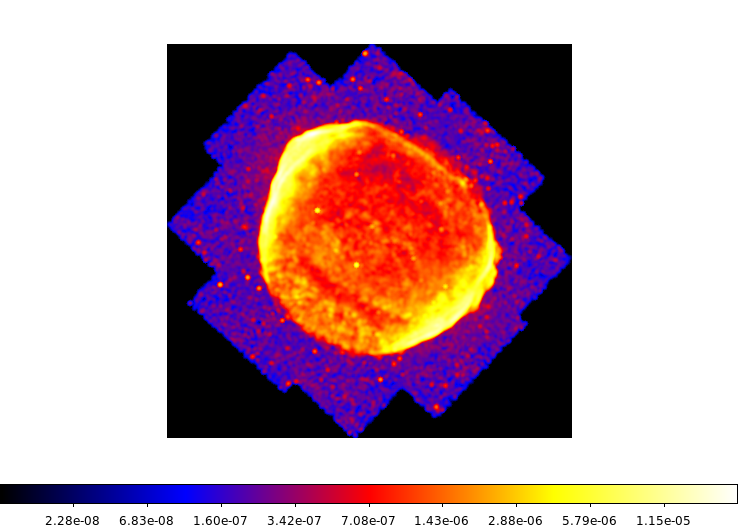

In [6]:
ds9 sn1006/broad_flux.img -scale log -block 4 -smooth -cmap b \
  -saveimage png ds9_01.png -quit

display < ds9_01.png

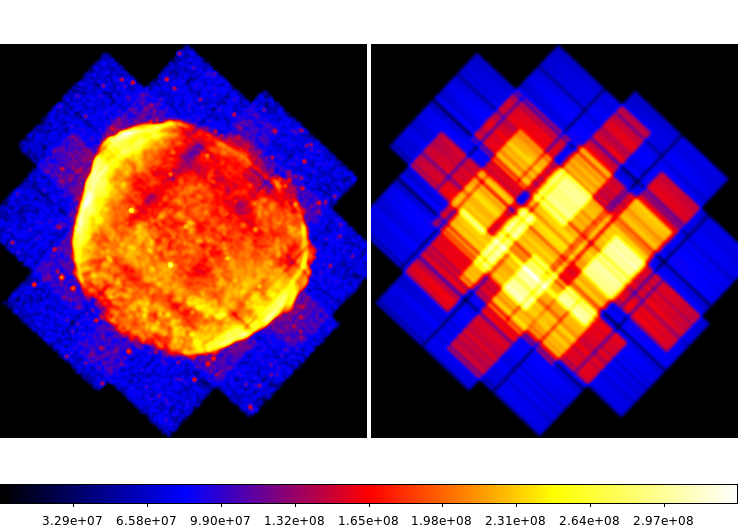

In [7]:
ds9 -scale log -block 4 -smooth -cmap b \
  sn1006/broad_thresh.img \
  sn1006/broad_thresh.expmap -scale linear \
  -saveimage png ds9_02.png -quit

display < ds9_02.png 

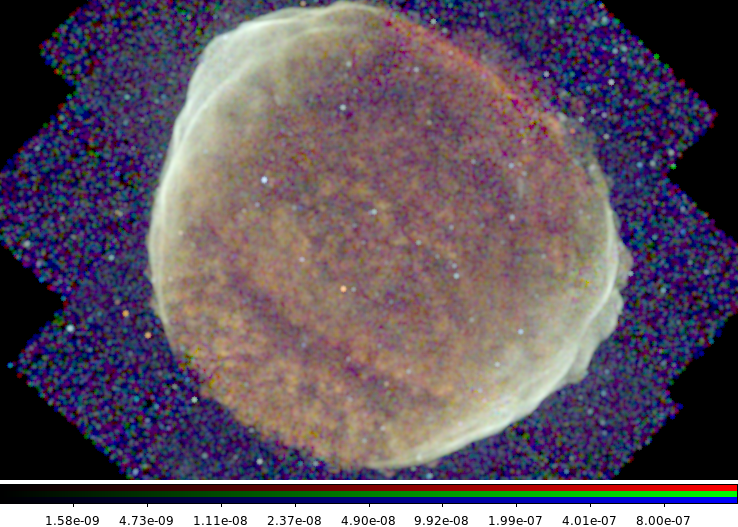

In [8]:
ds9 -block 2 -scale log -smooth -rgb \
  -red sn1006/soft_flux.img \
  -green sn1006/medium_flux.img \
  -blue sn1006/hard_flux.img \
   -saveimage png ds9_03.png -quit

display < ds9_03.png 

## Manual Step-by-Step

## Fluximage

In [9]:
punlearn fluximage
pset binsize=4
fluximage "3838/repro/*evt*[ccd_id=0:3]" manual/3838 clob+


pset: can't open parameter file : binsize=4
Running fluximage
Version: 12 September 2016

Using event file 3838/repro/acisf03838_repro_evt2.fits[ccd_id=0:3]
Using CSC ACIS broad science energy band.
Aspect solution 3838/repro/pcadf166171793N003_asol1.fits found.
Bad-pixel file 3838/repro/acisf03838_repro_bpix1.fits found.
Mask file 3838/repro/acisf03838_000N003_msk1.fits found.

The output images will have 370 by 371 pixels, pixel size of 3.936 arcsec,
    and cover x=2544.5:5504.5:8,y=2584.5:5552.5:8.

Running tasks in parallel with 4 processors.
Creating aspect histograms for obsid 3838
Creating 4 instrument maps for obsid 3838
Creating 4 exposure maps for obsid 3838
Combining 4 exposure maps for obsid 3838
Thresholding data for obsid 3838
Exposure-correcting image for obsid 3838

The following files were created:

 The clipped counts image is:
     manual/3838_broad_thresh.img

 The clipped exposure map is:
     manual/3838_broad_thresh.expmap

 The exposure-corrected image is:
    

In [10]:
for obsid in 4385 4386 4387 4388 4389 4390 4391 4392 4393 4394
do
   fluximage "${obsid}/repro/*evt*[ccd_id=0:3]" manual/${obsid} clob+
done

Running fluximage
Version: 12 September 2016

Using event file 4385/repro/acisf04385_repro_evt2.fits[ccd_id=0:3]
Using CSC ACIS broad science energy band.
Aspect solution 4385/repro/pcadf166192522N003_asol1.fits found.
Bad-pixel file 4385/repro/acisf04385_repro_bpix1.fits found.
Mask file 4385/repro/acisf04385_000N003_msk1.fits found.

The output images will have 370 by 370 pixels, pixel size of 3.936 arcsec,
    and cover x=2544.5:5504.5:8,y=2592.5:5552.5:8.

Running tasks in parallel with 4 processors.
Creating aspect histograms for obsid 4385
Creating 4 instrument maps for obsid 4385
Creating 4 exposure maps for obsid 4385
Combining 4 exposure maps for obsid 4385
Thresholding data for obsid 4385
Exposure-correcting image for obsid 4385

The following files were created:

 The clipped counts image is:
     manual/4385_broad_thresh.img

 The clipped exposure map is:
     manual/4385_broad_thresh.expmap

 The exposure-corrected image is:
     manual/4385_broad_flux.img

Running fluxima

In [11]:
/bin/ls -1 manual/*_broad_thresh.img

manual/3838_broad_thresh.img
manual/4385_broad_thresh.img
manual/4386_broad_thresh.img
manual/4387_broad_thresh.img
manual/4388_broad_thresh.img
manual/4389_broad_thresh.img
manual/4390_broad_thresh.img
manual/4391_broad_thresh.img
manual/4392_broad_thresh.img
manual/4393_broad_thresh.img
manual/4394_broad_thresh.img


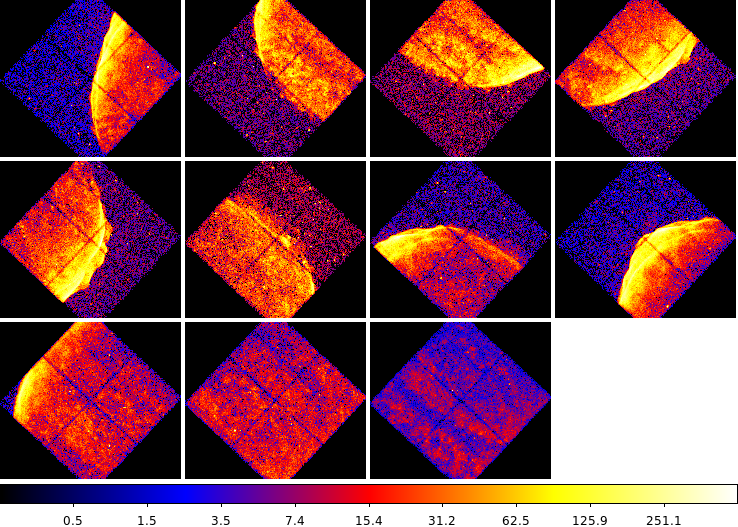

In [13]:
ds9 -block 2 -scale log -cmap b manual/*broad_thresh.img \
  -saveimage png ds9_04.png -quit

display < ds9_04.png 

In [14]:
ls manual/*_broad_thresh.img > images.lis

In [15]:
reproject_image_grid @images.lis sn1006.image \
  xsize=1500 ysize=1500 \
  xcenter=225.7 ycenter=-41.9 theta=0 pixelsize="0.033333'" clob+

BTIMDRFT values are different...FAIL...
BTIMNULL values are different...FAIL...
BTIMRATE values are different...FAIL...
omit - DEC_NOM values different more than 0.000300
omit - DEC_PNT values different more than 0.000300
omit - RA_NOM values different more than 0.000300
omit - RA_PNT values different more than 0.000300


In [16]:
dmhistory sn1006.image reproject_image_grid expand=no

reproject_image_grid infile="@images.lis" outfile="sn1006.image" xsize="1500" ysize="1500" xcenter="225.7" ycenter="-41.9" theta="0" pixelsize="0.033333'" projection="tan" resolution="1" method="sum" coord_sys="world" lookupTab="/export/ciao-4.9/data/dmmerge_header_lookup.txt" clobber="yes" verbose="0" 



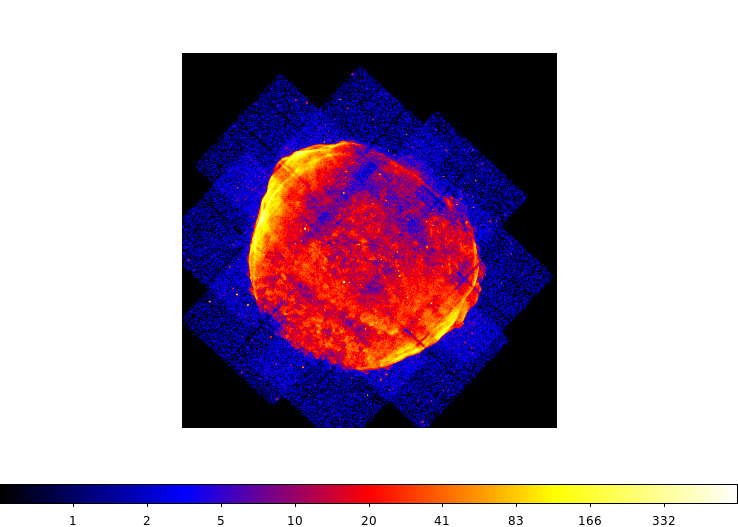

In [29]:
ds9 -scale log -cmap b -block 4 sn1006.image \
  -saveimage png ds9_05.png -quit

display < ds9_05.png

In [19]:
ls -1 manual/*_broad_thresh.expmap > expmaps.lis
head -5 expmaps.lis

manual/3838_broad_thresh.expmap
manual/4385_broad_thresh.expmap
manual/4386_broad_thresh.expmap
manual/4387_broad_thresh.expmap
manual/4388_broad_thresh.expmap


In [20]:
reproject_image @expmaps.lis sn1006.image sn1006.expmap method=average clob+

BTIMDRFT values are different...FAIL...
BTIMNULL values are different...FAIL...
BTIMRATE values are different...FAIL...
omit - DEC_NOM values different more than 0.000300
omit - DEC_PNT values different more than 0.000300
omit - RA_NOM values different more than 0.000300
omit - RA_PNT values different more than 0.000300


In [21]:
dmhistory sn1006.expmap reproject_image expand-

reproject_image infile="@expmaps.lis" matchfile="sn1006.image" outfile="sn1006.expmap" resolution="1" method="average" coord_sys="world" lookupTab="/export/ciao-4.9/data/dmmerge_header_lookup.txt" clobber="yes" verbose="0" 



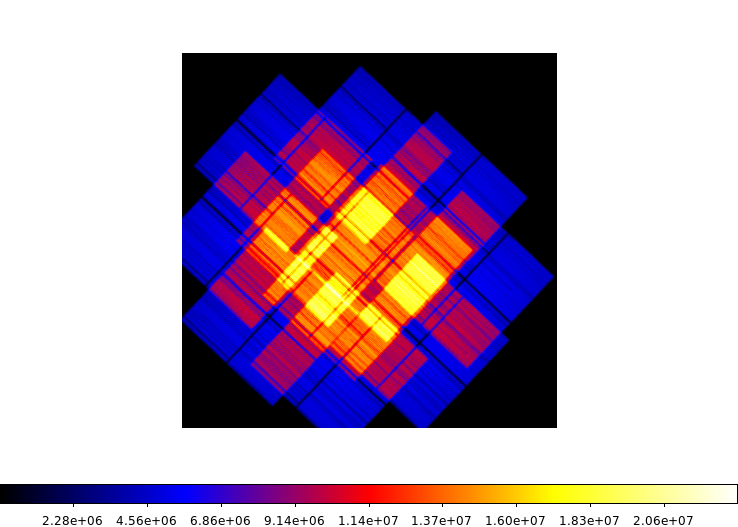

In [22]:
ds9 -cmap b -zoom 0.25 sn1006.expmap \
  -saveimage png ds9_06.png -quit

display < ds9_06.png

### Exposure Correct and Threshold

In [23]:
dmimgthresh sn1006.image sn1006_thresh.image expfile=sn1006.expmap cut=1.5% clob+
dmimgthresh sn1006.expmap sn1006_thresh.expmap cut=1.5% clob+

In [25]:
dmimgcalc sn1006.image sn1006.expmap sn1006.flux div clob+

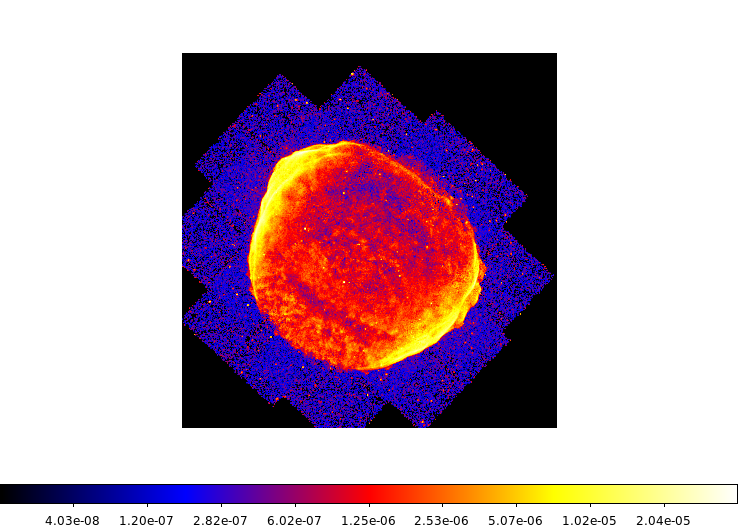

In [28]:
ds9 -block 4 -scale log -cmap b sn1006.flux \
   -saveimage png ds9_07.png -quit

display < ds9_07.png